<h1><b>Preprocesamiento de imagenes DWI / ADC</h1>

In [1]:
# Librerías
import os
import re
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from tqdm import tqdm
from skimage.transform import resize

In [16]:
# Rutas
BASE_DIR  = ".."
CENTRO    = "center_5"
SPLIT     = "test"

# Entrada
TRAIN_DIR  = f"{BASE_DIR}/imagenes/{SPLIT}/{CENTRO}/numpy"

# Salida
OUTPUT_DIR = f"{BASE_DIR}/preprocesamiento/output/{CENTRO}/preprocesamiento_{SPLIT}"

# Shape objetivo
TARGET_SIZE = (112, 112)
N_CHANNELS  = 2  # Canal 0: DWI | Canal 1: ADC

# Sufijos STROKE y CONTROL
ADC_SUFFIX = "_ADC.npy"
DWI_SUFFIX = "_DWI.npy"

print(f"Entrada : {TRAIN_DIR}")
print(f"Salida  : {OUTPUT_DIR}")

# Verificar carpeta de entrada
entrada = Path(TRAIN_DIR)
print(f"\n¿Existe la carpeta de entrada? {entrada.exists()}")

if entrada.exists():

    archivos = list(entrada.iterdir())
    adc = [f for f in archivos if f.name.endswith(ADC_SUFFIX)]
    dwi = [f for f in archivos if f.name.endswith(DWI_SUFFIX)]
    
    print(f"Total archivos : {len(archivos)}")
    print(f"ADC            : {len(adc)}")
    print(f"DWI            : {len(dwi)}")
    print(f"\nEjemplos de nombres:")

    for f in sorted(archivos)[:4]:
        print(f"  {f.name}")

# Crear carpeta de salida
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"\nCarpeta de salida lista: {OUTPUT_DIR}")

Entrada : ../imagenes/test/center_5/numpy
Salida  : ../preprocesamiento/output/center_5/preprocesamiento_test

¿Existe la carpeta de entrada? True
Total archivos : 514
ADC            : 257
DWI            : 257

Ejemplos de nombres:
  P0300_S0007_ADC.npy
  P0300_S0007_DWI.npy
  P0300_S0008_ADC.npy
  P0300_S0008_DWI.npy

Carpeta de salida lista: ../preprocesamiento/output/center_5/preprocesamiento_test


<h2><b>Emparejamiento de archivos por paciente</h2>

In [17]:
def get_sample_id(filename: str):
    return re.sub(r'_(ADC|DWI)\.npy$', '', filename)


train_path = Path(TRAIN_DIR)
adc_files  = sorted(train_path.glob(f"*{ADC_SUFFIX}"))

patients = []
sin_par  = []

for adc_path in adc_files:
    sample_id = get_sample_id(adc_path.name)
    dwi_path  = train_path / f"{sample_id}{DWI_SUFFIX}"

    if dwi_path.exists():
        patients.append({"id": sample_id, "adc": adc_path, "dwi": dwi_path})
    else:
        sin_par.append(sample_id)

print(f"Parejas encontradas : {len(patients)}")
print(f"Sin par DWI         : {len(sin_par)}")
print(f"\nEjemplos:")
for p in patients[:5]:
    print(f"  {p['id']}")

Parejas encontradas : 257
Sin par DWI         : 0

Ejemplos:
  P0300_S0007
  P0300_S0008
  P0300_S0009
  P0300_S0010
  P0300_S0011


<h2><b> Carga y verificación</h2>

In [18]:
# EMPAREJAMIENTO Y VERIFICACIÓN
data = []

for p in tqdm(patients, desc="Cargando"):
    dwi, adc = np.load(p["dwi"]), np.load(p["adc"])
    data.append({"id": p["id"], "dwi": dwi, "adc": adc})

print(f"\nTotal cargados: {len(data)}")

# Verificación rápida con 3 ejemplos
print("\nEjemplos:")
for d in data[:3]:
    print(f"  {d['id']}")
    print(f"    DWI shape: {d['dwi'].shape} | min: {d['dwi'].min():.4f} | max: {d['dwi'].max():.4f}")
    print(f"    ADC shape: {d['adc'].shape} | min: {d['adc'].min():.6f} | max: {d['adc'].max():.6f}")

Cargando: 100%|██████████| 257/257 [00:01<00:00, 151.31it/s]


Total cargados: 257

Ejemplos:
  P0300_S0007
    DWI shape: (256, 256) | min: 0.0000 | max: 317.0000
    ADC shape: (256, 256) | min: 0.000000 | max: 4095.000000
  P0300_S0008
    DWI shape: (256, 256) | min: 0.0000 | max: 317.0000
    ADC shape: (256, 256) | min: 0.000000 | max: 4095.000000
  P0300_S0009
    DWI shape: (256, 256) | min: 0.0000 | max: 317.0000
    ADC shape: (256, 256) | min: 0.000000 | max: 4095.000000


<h2><b> Normalización  y risize</h2>

In [20]:
# Z-SCORE todos los 3040

def zscore_normalize(img: np.ndarray, bg_value: float = -3.0):
    result       = np.full_like(img, fill_value=bg_value, dtype=np.float32)
    brain_mask   = img > 0
    brain_pixels = img[brain_mask]
    result[brain_mask] = (brain_pixels - brain_pixels.mean()) / brain_pixels.std()
    return result

def resize_img(img: np.ndarray, size: tuple = TARGET_SIZE) -> np.ndarray:
    """
    Resize a (H, W) manteniendo el fondo en -3.
    anti_aliasing suaviza bordes al reducir tamaño.
    """
    return resize(
        img, size, order=1, mode = "constant", 
        cval=-3.0, anti_aliasing = True
        ).astype(np.float32)

<h2><b> Stack dual channel

In [21]:
# Recarga + zscore + resize + stack + guardar
output_path = Path(OUTPUT_DIR)
data = []

for p in tqdm(patients, desc="Procesando"):
    dwi = np.load(p["dwi"])
    adc = np.load(p["adc"])

    # Z-score
    dwi = zscore_normalize(dwi)
    adc = zscore_normalize(adc)

    # Resize si es necesario
    if dwi.shape != TARGET_SIZE:
        dwi = resize_img(dwi)
    if adc.shape != TARGET_SIZE:
        adc = resize_img(adc)

    # Stack (2, 112, 112)
    stacked = np.stack([dwi, adc], axis=0)
    np.save(output_path / f"{p['id']}.npy", stacked)
    data.append({"id": p["id"], "dwi": dwi, "adc": adc})

print(f"\nGuardados: {len(list(output_path.glob('*.npy')))}")
print("\nVerificación (3 primeros):")
for d in data[:3]:
    loaded = np.load(output_path / f"{d['id']}.npy")
    print(f"  {d['id']} → shape: {loaded.shape}")

Procesando: 100%|██████████| 257/257 [00:01<00:00, 247.66it/s]


Guardados: 257

Verificación (3 primeros):
  P0300_S0007 → shape: (2, 112, 112)
  P0300_S0008 → shape: (2, 112, 112)
  P0300_S0009 → shape: (2, 112, 112)


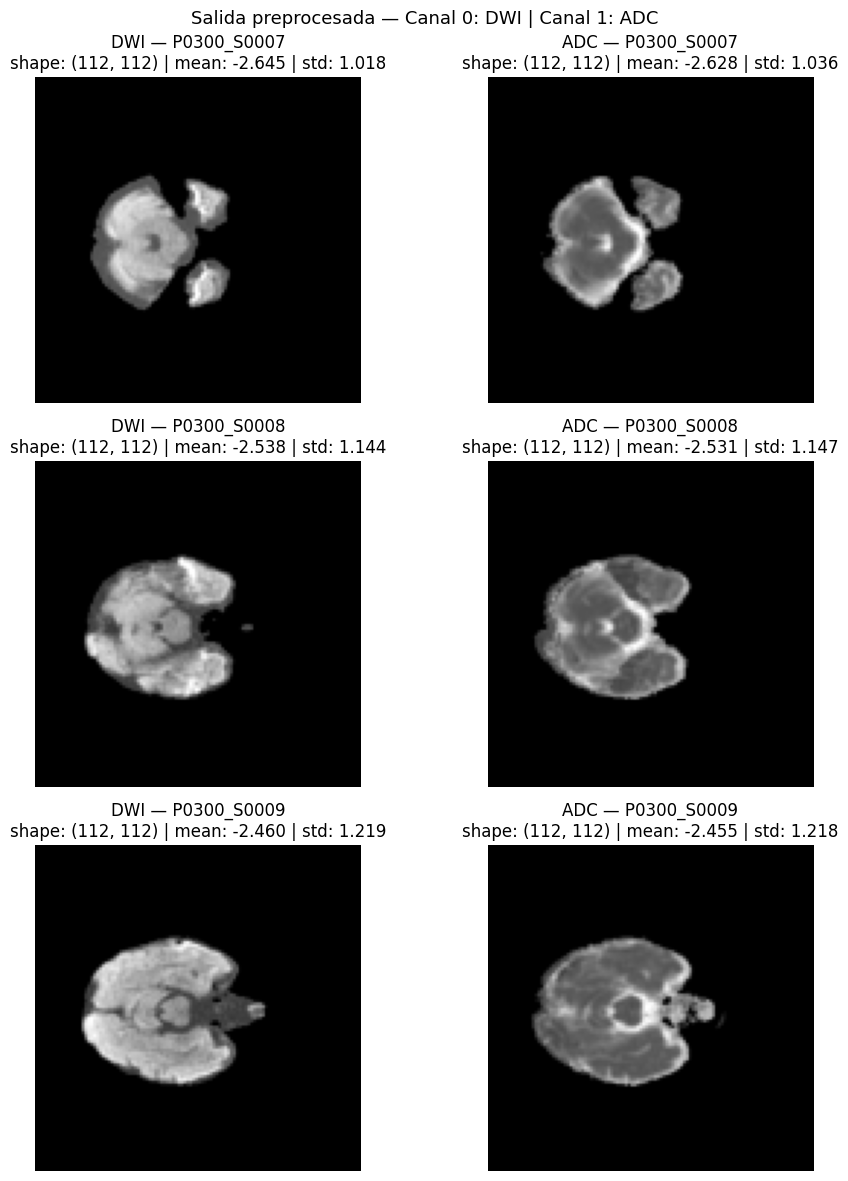

In [22]:
# Visualización rápida de un ejemplo
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

for i, d in enumerate(data[:3]):
    loaded = np.load(output_path / f"{d['id']}.npy")
    
    dwi = loaded[0]  # Canal 0: DWI
    adc = loaded[1]  # Canal 1: ADC

    axes[i, 0].imshow(dwi, cmap="gray")
    axes[i, 0].set_title(f"DWI — {d['id']}\nshape: {dwi.shape} | mean: {dwi[dwi!=0].mean():.3f} | std: {dwi[dwi!=0].std():.3f}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(adc, cmap="gray")
    axes[i, 1].set_title(f"ADC — {d['id']}\nshape: {adc.shape} | mean: {adc[adc!=0].mean():.3f} | std: {adc[adc!=0].std():.3f}")
    axes[i, 1].axis("off")

plt.suptitle("Salida preprocesada — Canal 0: DWI | Canal 1: ADC", fontsize=13)
plt.tight_layout()
plt.show()

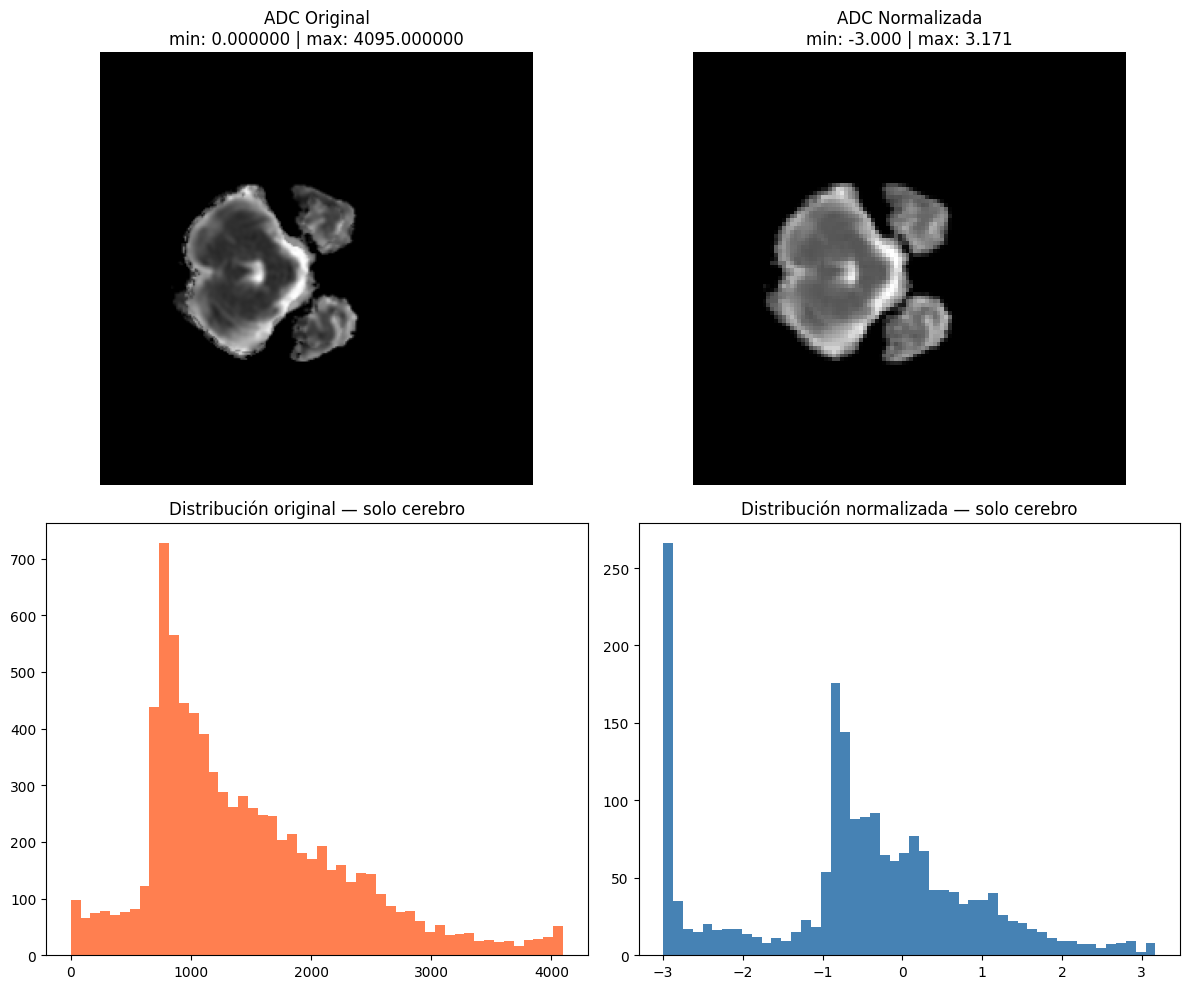

In [23]:
# COMPARACIÓN: ORIGINAL vs NORMALIZADA

# original
original_adc = np.load(patients[0]["adc"])
normalizada_adc = data[0]["adc"]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Imágenes
axes[0, 0].imshow(original_adc, cmap="gray")
axes[0, 0].set_title(f"ADC Original\nmin: {original_adc.min():.6f} | max: {original_adc.max():.6f}")
axes[0, 0].axis("off")

axes[0, 1].imshow(normalizada_adc, cmap="gray")
axes[0, 1].set_title(f"ADC Normalizada\nmin: {normalizada_adc.min():.3f} | max: {normalizada_adc.max():.3f}")
axes[0, 1].axis("off")

# Histogramas solo cerebro
brain_orig = original_adc[original_adc > 0]
brain_norm = normalizada_adc[normalizada_adc != -3.0]

axes[1, 0].hist(brain_orig, bins=50, color="coral")
axes[1, 0].set_title("Distribución original — solo cerebro")

axes[1, 1].hist(brain_norm, bins=50, color="steelblue")
axes[1, 1].set_title("Distribución normalizada — solo cerebro")

plt.tight_layout()
plt.show()